In [ ]:
import os
import re
import time
import random
import requests
import pandas as pd
import json
import threading
 
from pathlib import Path
from pydantic import BaseModel, Field
from helpers import get_content
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from openai import OpenAI
from typing import List, Dict, Any


df = pd.read_csv('rna_seq_data/rna_seq_gds_with_publication_filtered.csv')
df_temp = pd.read_csv('rna_seq_data/clinical_specimen_gseids.csv')
df = df[df['accession'].isin(df_temp['gseid'])]

missing = df[['pmcids', 'pmids']].isna().any(axis=1)
if missing.any():
    df = df[~missing]
assert df[['pmcids', 'pmids']].isna().sum().sum() == 0

df

,gds_uid,accession,pmids,pmcids
6,200270967,GSE270967,39125649,PMC11311431
10,200275628,GSE275628,39244627,PMC11473817
17,200238195,GSE238195,39904979,PMC11794601
37,200254362,GSE254362,39310771,PMC11416675
39,200274983,GSE274983,39395787,PMC11949723
...,...,...,...,...
10743,200033328,GSE33328,22199257,PMC3315322
10754,200029006,GSE29006,21636547,PMC3694393
10757,200022260,GSE22260,21571633,PMC3107329
10764,200024283,GSE24283,21261984,PMC3041646


In [8]:
same_count = df['pmcids'].str.count(';') == df['pmids'].str.count(';')
df_pairs = df[same_count]
pmcids_exploded = df_pairs['pmcids'].str.split(';').explode().str.strip().reset_index(drop=True)
pmids_exploded = df_pairs['pmids'].str.split(';').explode().str.strip().reset_index(drop=True)
assert len(pmcids_exploded) == len(pmids_exploded), "explode must yield same length (same_count filter)"

# gse_exploded = df_pairs['accession'].repeat(df_pairs['pmcids'].str.split(';').str.len()).reset_index(drop=True)
pmc_pmid_map = list(set(zip(pmcids_exploded, pmids_exploded)))
print("We have total of {} papers with both PMC and PMID".format(len(pmc_pmid_map)))

We have total of 1319 papers with both PMC and PMID


In [9]:
SYSTEM_PROMPT = """You are an expert biomedical text-mining assistant.

[OBJECTIVE]
Your task is to determine whether a primary research study includes **survival analysis** (i.e., an analysis using time-to-event data) as part of its methods and results. You must classify the text as YES, NO, or UNCLEAR.

[DEFINITION]
**Survival analysis** includes statistical methods applied to time-to-event data (e.g., Kaplan-Meier curves, Cox proportional hazards models, log-rank tests, restricted mean survival time, etc.). 

[CRITERIA]
Criteria for *YES* (The text must demonstrate AT LEAST ONE of the following regarding primary data):
    - It is clearly stated that the study analyzes survival/time-to-event data.
    - The study explicitly states conducting survival analysis in its methods (e.g., using Kaplan-Meier, Cox models, log-rank tests).
    - Results derived from time-to-event analysis are presented (e.g., survival curves, hazard ratios, p-values specifically for time-to-event outcomes).

Criteria for *NO* (Flag as NO if the text matches ANY of these, or lacks survival analysis entirely):
    - "Survival" refers to in-vitro cell viability assays (e.g., cell survival) rather than clinical/in-vivo time-to-event data.
    - "Survival" is reported only as a simple binary proportion or percentage (e.g., "the 5-year survival rate was 80%") WITHOUT any indication of time-to-event statistical methods.
    - Survival terms are used only for background, context, or citing the importance of survival outcomes.
    - Survival results from *other studies* are cited/discussed (including Systematic Reviews or Meta-Analyses pooling older data), but no *new* primary time-to-event analysis is performed.
    - The text describes a *future study design* or protocol involving survival analysis.
    - Survival analysis is mentioned only as a limitation or *future direction*.

Criteria for *UNCLEAR* (Default to this if ambiguous):
    - The text mentions "survival" as an outcome, but is too brief, truncated, or lacks sufficient methodological detail to definitively determine if time-to-event statistics were used vs. simple binary proportions.
    - The language is highly ambiguous, making it impossible to confidently assign YES or NO.

[INSTRUCTIONS]
1) Carefully read the text and extract exact quotes that serve as evidence for your classification. If there is no mention of survival at all, return an empty array for the evidence: [].
2) Synthesize your findings into a brief 1-2 sentence reasoning.
3) Assign the final classification based strictly on the criteria above.
4) Output strictly in the requested JSON format. Do not include any conversational text, pleasantries, or markdown outside of the JSON object.

[OUTPUT FORMAT (STRICT)]
Return ONLY a valid JSON object matching this exact structure:

{
  "classification": "YES, NO, or UNCLEAR",
  "evidence": [
    "Exact quote 1 from the text",
    "Exact quote 2 from the text", 
    ...
  ],
  "reasoning": "1-2 sentences explaining why the evidence dictates the classification based on the criteria."
}"""


def fetch_bioc_json(article_id: str) -> dict | None:
    url = f'https://www.ncbi.nlm.nih.gov/research/bionlp/RESTful/pmcoa.cgi/BioC_json/{article_id}/unicode'
    r = requests.get(url)
    if r.status_code != 200:
        return None
    data = r.json()
    if not data:
        return None
    return data[0]


input_prompts = []

out_dir = 'rna_seq_data/bioCjson_raw'
for pmcid, pmid in pmc_pmid_map:
    path = f'{out_dir}/{pmcid}.json.gz'
    try:
        content = get_content(path)
    except Exception:
        # print(f'No content for {pmcid} / {pmid}', flush=True)
        continue
        # bioc = fetch_bioc_json(pmcid)
        # if bioc is None:
        #     continue
        # with gzip.open(path, 'wt') as f:
        #     f.write(json.dumps(bioc, indent=2))
        # print(f'{pmcid} / {pmid} saved', flush=True)
        # content = get_content(path)

    USER_PROMPT = f"Research article:\n\nTITLE:{content['TITLE']}\nABSTRACT:{content['ABSTRACT']}\nCONTENT:{content['CONTENT'] + content['FIG_CAPTIONS'] + content['SUPPL']}\n\n"

    # Store as a list of messages (standard chat format)
    input_prompts.append({
        "pmcid": pmcid,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT}
        ]
    })


with open("rna_seq_data/survival-analysis-classification-prompts.jsonl", "w") as f:
    for prompt in input_prompts:
        f.write(json.dumps(prompt) + "\n")

In [10]:
import statistics
import tiktoken

prompts_path = "rna_seq_data/survival-analysis-classification-prompts.jsonl"
enc = tiktoken.get_encoding("o200k_base")

user_token_counts = []

with open(prompts_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        user_text = "\n".join(
            str(m.get("content", ""))
            for m in item.get("messages", [])
            if m.get("role") == "user"
        )

        user_token_counts.append(len(enc.encode(user_text)))

total_prompts = len(user_token_counts)
total_user_tokens = sum(user_token_counts)
mean_tokens = statistics.mean(user_token_counts) if user_token_counts else 0
median_tokens = statistics.median(user_token_counts) if user_token_counts else 0

system_prompt_tokens_single = len(enc.encode(SYSTEM_PROMPT))
total_system_tokens = system_prompt_tokens_single * total_prompts

print(f"Tokenizer: {enc.name}")
print(f"Total prompts: {total_prompts}")
print(f"Total user tokens: {total_user_tokens:,}")
print(f"Average user tokens per prompt: {mean_tokens:.2f}")
print(f"Median user tokens per prompt: {median_tokens:.2f}")
print(f"System prompt tokens (single): {system_prompt_tokens_single:,}")
print(f"Total system tokens (reused across all prompts): {total_system_tokens:,}")

Tokenizer: o200k_base
Total prompts: 1207
Total user tokens: 12,377,297
Average user tokens per prompt: 10254.60
Median user tokens per prompt: 9442.00
System prompt tokens (single): 659
Total system tokens (reused across all prompts): 795,413


In [ ]:
class ClassificationResponse(BaseModel):
    """Structured output schema for transcriptomic source classification."""
    classification: str = Field(description="YES, NO, or UNCLEAR")
    evidence: List[str] = Field(description="Direct quotes from the text that support the classification.")
    reasoning: str = Field(description="1-2 sentences explaining why those phrases dictate the classification.")


# OpenAI reads OPENAI_API_KEY from the environment.
client = OpenAI()

def _call_openai(messages: List[Dict[str, Any]]) -> Any:
    # Responses API uses "input" + "input_text" content type
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": [{"type": "input_text", "text": msg["content"]}],
        })

    # client.responses.parse is the correct method for:
    # - structured output (text_format param)
    # - reasoning effort
    # - input_text content type
    resp = client.responses.parse(
        model="gpt-5.2-2025-12-11", # gpt-5-nano-2025-08-07
        input=formatted_messages,
        text_format=ClassificationResponse,  # Pydantic model for structured output
        reasoning={"effort": "medium"},
        service_tier="flex"
    )

    # Result is accessed via resp.output_parsed, not resp.choices[0]
    return resp.output_parsed, resp.usage


def _call_openrouter(messages: List[Dict[str, Any]]) -> Any:
    # IMPORTANT: Use standard create(), not responses.parse() for OSS models
    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        # To force DeepInfra and ensure consistent pricing:
        extra_body={
            "provider": {
                "order": ["DeepInfra"],
                "allow_fallbacks": False
            },
            # Since we can't use 'text_format', we use 'response_format'
            "response_format": {"type": "json_object"}
        }
    )

    content = resp.choices[0].message.content
    if not isinstance(content, str):
        raise TypeError(f"Expected JSON string content, got {type(content).__name__}")

    content = content.strip()
    if not content:
        raise ValueError("OpenRouter returned empty content")

    parsed = ClassificationResponse.model_validate_json(content)

    usage = resp.usage
    input_tokens = getattr(usage, "input_tokens", None)
    if input_tokens is None:
        input_tokens = getattr(usage, "prompt_tokens", None)

    output_tokens = getattr(usage, "output_tokens", None)
    if output_tokens is None:
        output_tokens = getattr(usage, "completion_tokens", None)

    token_details = getattr(usage, "input_tokens_details", None)
    if token_details is None:
        token_details = getattr(usage, "prompt_tokens_details", None)

    usage_details = {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cached_tokens": getattr(token_details, "cached_tokens", None) if token_details is not None else None,
        "total_tokens": getattr(usage, "total_tokens", None),
    }

    return parsed, usage_details



input_prompts = []
with open("rna_seq_data/survival-analysis-classification-prompts.jsonl", "r") as f:
    for line in f:
        if line.strip():
            input_prompts.append(json.loads(line))

results_file = "rna_seq_data/survival-analysis-classification-results-5.2.jsonl"
computed_pmcids = set()

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            result_data = json.loads(line)
            computed_pmcids.add(str(result_data.get("pmcid")).strip())

pending_prompts = [
    p for p in input_prompts
    if p.get("pmcid") not in computed_pmcids
]

print(f"Found {len(computed_pmcids)} already computed submissions")
print(f"Processing {len(pending_prompts)} remaining submissions")

# raise Exception("Stop here")

MAX_WORKERS = 14
write_lock = threading.Lock()


def _worker(prompt_data, file_handle):
    pmcid = prompt_data["pmcid"]
    messages = prompt_data["messages"]

    try:
        parsed, usage = _call_openai(messages)
        # parsed, usage = _call_openrouter(messages)  # For OpenRouter, use this line instead
        usage_data = usage.model_dump() if hasattr(usage, "model_dump") else usage
        result_data = {
            "pmcid": pmcid,
            "response": parsed.model_dump(),
            "usage": usage_data,
        }

        line = json.dumps(result_data, ensure_ascii=False) + "\n"
        with write_lock:
            file_handle.write(line)
            file_handle.flush()

        return {"ok": True, "pmcid": pmcid}
    except Exception as e:
        return {"ok": False, "pmcid": pmcid, "error": str(e)}

results_count = 0
error_count = 0
completed_count = 0

with open(results_file, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_worker, p, out_f) for p in pending_prompts]

        for future in as_completed(futures):
            completed_count += 1
            info = future.result()

            if info["ok"]:
                results_count += 1
                if results_count % 10 == 0:
                    print(f"Processed {results_count} submissions...")
            else:
                error_count += 1
                print(f"Error processing {info['gseid']}: {info['error']}")

print(f"Completed! Processed {results_count} new submissions ({error_count} errors)")

# Save the current run in the format expected by the next notebook.
current_rows = []
with open(results_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        current_rows.append({
            "pmcid": str(item.get("pmcid", "")).strip(),
            "classification": (item.get("response") or {}).get("classification"),
        })
current_results_df = pd.DataFrame(current_rows, columns=["pmcid", "classification"])
current_results_df = current_results_df.drop_duplicates(subset=["pmcid"], keep="last")
selected = current_results_df.loc[current_results_df["classification"] == "YES", ["pmcid"]]
output_path = "rna_seq_data/survival-analysis-papers.csv"
selected.to_csv(output_path, index=False)
print(f"Saved {len(selected)} survival-analysis papers to {output_path}")


Found 0 already computed submissions
Processing 73 remaining submissions
Processed 10 submissions...
Processed 20 submissions...
Processed 30 submissions...
Processed 40 submissions...
Processed 50 submissions...
Processed 60 submissions...
Processed 70 submissions...
Completed! Processed 73 new submissions (0 errors)


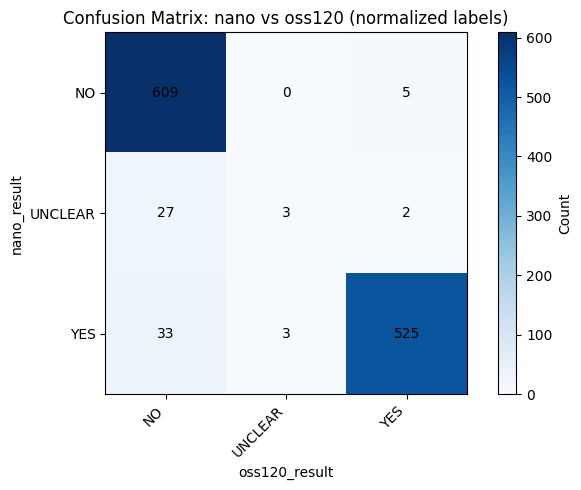

nano_result
NO         614
YES        561
UNCLEAR     32
Name: count, dtype: int64
oss120_result
NO         669
YES        532
UNCLEAR      6
Name: count, dtype: int64


In [11]:
# OPTIONAL ANALYSIS: skip this cell and the cells below it on a first run.
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

nano_path = Path("rna_seq_data/survival-analysis-classification-results-nano.jsonl")
oss120_path = Path("rna_seq_data/survival-analysis-classification-results-oss120.jsonl")
gpt52_path = Path("rna_seq_data/survival-analysis-classification-results-5.2.jsonl")


def _normalize_label(label):

#     if label is None:
#         return None

#     value = " ".join(str(label).strip().upper().split())

#     if "CLINICAL" in value or "PATIENT" in value or "BIOSPECIMEN" in value:
#         return "CLINICAL SPECIMEN"
#     if "LAB" in value or "EXPERIMENT" in value or "MODEL" in value:
#         return "LAB MODEL"
#     if "UNCLEAR" in value or "INSUFFICIENT" in value or "VAGUE" in value:
#         return "UNCLEAR"

    return label


def _load_classifications(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = item.get("pmcid")
            classification = _normalize_label((item.get("response") or {}).get("classification"))
            if gseid:
                records[str(gseid).strip()] = classification
    return records


nano_results = _load_classifications(nano_path)
oss120_results = _load_classifications(oss120_path)

all_pmcids = sorted(set(nano_results) | set(oss120_results))
df_results = pd.DataFrame(
    {
        "pmcid": all_pmcids,
        "nano_result": [nano_results.get(gseid) for gseid in all_pmcids],
        "oss120_result": [oss120_results.get(gseid) for gseid in all_pmcids],
    }
)

cm = pd.crosstab(
    df_results["nano_result"].fillna("MISSING"),
    df_results["oss120_result"].fillna("MISSING"),
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_title("Confusion Matrix: nano vs oss120 (normalized labels)")
ax.set_xlabel("oss120_result")
ax.set_ylabel("nano_result")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


print(df_results['nano_result'].value_counts())
print(df_results['oss120_result'].value_counts())

In [12]:

mismatch = df_results["nano_result"] != df_results["oss120_result"]
# mismatch_count = mismatch.sum()
# print(f"Number of gseids where normalized nano_result != normalized oss120_result: {mismatch_count}")

mismatch_pmcids = set(df_results.loc[mismatch, "pmcid"].tolist())
unclear_pmcids = set(df_results.loc[(df_results["nano_result"] == "UNCLEAR") | (df_results["oss120_result"] == "UNCLEAR"), "pmcid"].tolist())

print(f"Number of pmcids where normalized nano_result != normalized oss120_result: {len(mismatch_pmcids)}")
print(f"Number of pmcids where either nano_result or oss120_result is UNCLEAR: {len(unclear_pmcids)}")

total_pmcids = mismatch_pmcids | unclear_pmcids
print("Total number of pmcids:", len((total_pmcids)))



Number of pmcids where normalized nano_result != normalized oss120_result: 70
Number of pmcids where either nano_result or oss120_result is UNCLEAR: 35
Total number of pmcids: 73


In [17]:
gpt52_results = _load_classifications(gpt52_path)

# Keep agreement labels by default.
df_final = df_results.copy()
df_final["final_label"] = df_final["oss120_result"]

# Replace the 239 mismatch/UNCLEAR gseids with GPT-5.2 labels.
update_mask = df_final["pmcid"].isin(total_pmcids)
df_final.loc[update_mask, "final_label"] = df_final.loc[update_mask, "pmcid"].map(gpt52_results)

missing_updates = sorted(g for g in total_pmcids if g not in gpt52_results)
if missing_updates:
    print(f"Warning: GPT-5.2 labels missing for {len(missing_updates)} pmcids")

final_counts = df_final["final_label"].value_counts(dropna=False)
final_pct = (final_counts / len(df_final) * 100).round(2)

print(f"Total pmcids: {len(df_final)}")
print(f"Updated with GPT-5.2: {int(update_mask.sum())}")
print("\nFinal label distribution (after GPT-5.2 updates):")
print(final_counts)
print("\nFinal label distribution (%):")
print(final_pct)


df_final[df_final['final_label'] == 'YES']['pmcid'].to_csv('rna_seq_data/survival-analysis-papers.csv', index=False)

Total pmcids: 1207
Updated with GPT-5.2: 73

Final label distribution (after GPT-5.2 updates):
final_label
NO         636
YES        555
UNCLEAR     16
Name: count, dtype: int64

Final label distribution (%):
final_label
NO         52.69
YES        45.98
UNCLEAR     1.33
Name: count, dtype: float64


In [15]:
df_final[df_final['final_label'] == 'YES']

,pmcid,nano_result,oss120_result,final_label
4,PMC10039058,YES,YES,YES
9,PMC10066286,YES,YES,YES
10,PMC10066387,YES,YES,YES
11,PMC10071545,YES,YES,YES
13,PMC10076022,YES,YES,YES
...,...,...,...,...
1200,PMC9970024,YES,YES,YES
1201,PMC9972164,YES,YES,YES
1202,PMC9972689,YES,YES,YES
1205,PMC9986713,YES,YES,YES
